# Load Data

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define columns used as multivariate time-series features
TS_FEATURE_COLS = [
    "tbl_speed",
    "fom",
    "main_comp",
    "tbl_fill",
    "SREL",
    "pre_comp",
    "produced",
    "waste",
    "cyl_main",
    "cyl_pre",
    "stiffness",
    "ejection"
]

TARGET_COLS = ["total_waste", "Total impurities"]

# Load process-level targets
print("Loading Process.csv (targets)...")
process = pd.read_csv("data/Process.csv", sep=";")      

# Keep only the necessary columns
cols = ["batch", "code"] + TARGET_COLS
process = process[cols]

# Drop batches that do not have valid target values
process = process.dropna(subset=TARGET_COLS).reset_index(drop=True)
print(f"Process targets shape: {process.shape}")

# Normalize time-series feature columns
norm = pd.read_csv("data/Normalization.csv", sep=";")

# Merge normalization factor onto each batch via product code
process = process.merge(norm[["Product code", "Normalisation factor"]], how="left", left_on="code", right_on="Product code")

for col in TARGET_COLS:
    process[col] = process[col] / process["Normalisation factor"]
    
    
# Load and concatenate all time-series CSV files
print("\nLoading time-series CSV files...")
dfs = []
for i in range(1, 26):
    df = pd.read_csv(f"data/Time-Series/{i}.csv", sep=";")
    dfs.append(df)
    
ts = pd.concat(dfs, ignore_index=True)
print(f"Time-series shape: {ts.shape}")

#Keep only time-series rows for batches that have valid (normalized) targets
valid_batches = set(process["batch"].unique())
ts = ts[ts["batch"].isin(valid_batches)].copy()

#Map Normalisation factor onto each time-series row via batch
factor_map = process[["batch", "Normalisation factor"]].drop_duplicates("batch")
ts = ts.merge(factor_map, on="batch", how="left")

#Normalize ONLY count-type TS variables aka those that scale with batch size
COUNT_TS_COLS = ["produced", "waste"]
for col in COUNT_TS_COLS:
    if col in ts.columns:
        ts[col] = ts[col] / ts["Normalisation factor"]

#Drop the helper column bc don't need it later
ts = ts.drop(columns=["Normalisation factor"])

Loading Process.csv (targets)...
Process targets shape: (987, 4)

Loading time-series CSV files...
Time-series shape: (4720208, 16)


# Build Sequences

In [14]:
# Keep only time-series data whose batch IDs appear in the process targets
valid_batches = set(process["batch"].unique())
ts = ts[ts["batch"].isin(valid_batches)].copy()

# Fill missing feature values within each batch
def fill_group(g):
    g = g.copy()
    g = g.ffill()         # forward fill missing values
    g = g.bfill()         # backward fill any remaining gaps
    g = g.fillna(0.0)     # fill any remaining NaNs with 0.0
    return g

# Apply the filling function to each batch
ts[TS_FEATURE_COLS] = ts.groupby("batch")[TS_FEATURE_COLS].transform(fill_group)

# Compute the number of time steps for each batch
batch_lengths = ts.groupby("batch").size()

# Get the distribution of sequence lengths and its 95th percentile
p95 = np.percentile(batch_lengths.to_numpy(), 95)

# Define the maximum sequence length to control memory usage
max_seq_len = int(min(p95, 5000))
print(f"Maximum sequence length: {max_seq_len}")

# Sort batch IDs for reproducible ordering
batch_ids = sorted(batch_lengths.index)

X_list, y_list = [], []
for b in batch_ids:
    # Extract feature matrix (T, C) for each batch
    g = ts[ts["batch"] == b]
    seq = g[TS_FEATURE_COLS].values.astype(np.float32)
    
    # Truncate or pad to maximum sequence length
    if seq.shape[0] >= max_seq_len:
        seq = seq[:max_seq_len, :]
    else:
        pad_len = max_seq_len - seq.shape[0]
        pad = np.zeros((pad_len, seq.shape[1]), dtype=np.float32)
        seq = np.vstack([seq, pad])
        
    # Align each batch with its target values
    row = process.loc[process["batch"] == b, TARGET_COLS]
    y = row.iloc[0].values.astype(np.float32)
    
    X_list.append(seq)
    y_list.append(y)

X = np.stack(X_list, axis=0)    # (num_batches, T, C)
y = np.stack(y_list, axis=0)    # (num_batches, 2)

print(f"Built sequences with X shape: {X.shape}, y shape: {y.shape}")

Maximum sequence length: 5000
Built sequences with X shape: (987, 5000, 12), y shape: (987, 2)


# Train/Validation Split

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_batches, T, C = X.shape

# Scale input features per-channel over all timesteps and batches
X_reshaped = X.reshape(-1, C)  # Flatten: (num_batches * T, C)

x_scaler = StandardScaler()
X_scaled_reshaped = x_scaler.fit_transform(X_reshaped)

# Restore original structure: (num_batches, T, C)
X_scaled = X_scaled_reshaped.reshape(num_batches, T, C).astype(np.float32)

# Scale target variables over the 2D target array
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y).astype(np.float32)

# Split batches into training and validation sets
X_t, X_v, y_t, y_v = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_t.shape}, y_train shape: {y_t.shape}")
print(f"X_val shape: {X_v.shape}, y_val shape: {y_v.shape}")

X_train shape: (789, 5000, 12), y_train shape: (789, 2)
X_val shape: (198, 5000, 12), y_val shape: (198, 2)


# Build and Train CNN

In [16]:
import importlib
import utils.cnn as cnn
importlib.reload(cnn)

from utils.cnn import CNN_trainer

# Build and train the model
cnn_trainer = CNN_trainer(
    X_t, y_t, 
    X_v, y_v,
    epochs=100,         # Number of epochs
    batch_size=128,     # Batch size
    lr=1e-3,            # Learning rate
    l2=1e-5,            # L2 regularization coefficient
)
cnn_trainer.run()


Training Epoch 1/100
7/7 - loss: 0.8822 - MAE: 0.6974 - val_loss: 0.6401 - val_MAE: 0.5633
Learning rate: 0.001000
Validation MAE improved to 0.5633
Saved best model weights to 'best_model_weights.h5'

Training Epoch 2/100
7/7 - loss: 0.6379 - MAE: 0.4864 - val_loss: 0.5479 - val_MAE: 0.5330
Learning rate: 0.001000
Validation MAE improved to 0.5330
Saved best model weights to 'best_model_weights.h5'

Training Epoch 3/100
7/7 - loss: 0.5586 - MAE: 0.4688 - val_loss: 0.5130 - val_MAE: 0.5399
Learning rate: 0.000999
No improvement (patience: 1/5)

Training Epoch 4/100
7/7 - loss: 0.4610 - MAE: 0.4374 - val_loss: 0.4774 - val_MAE: 0.5153
Learning rate: 0.000998
Validation MAE improved to 0.5153
Saved best model weights to 'best_model_weights.h5'

Training Epoch 5/100
7/7 - loss: 0.5616 - MAE: 0.4244 - val_loss: 0.4436 - val_MAE: 0.4850
Learning rate: 0.000996
Validation MAE improved to 0.4850
Saved best model weights to 'best_model_weights.h5'

Training Epoch 6/100
7/7 - loss: 0.5523 - MA

# Build and Train LSTM

In [17]:
import importlib
import utils.lstm as lstm
importlib.reload(lstm)

from utils.lstm import LSTM_trainer

lstm_trainer = LSTM_trainer(
    X_t, y_t, 
    X_v, y_v, 
    epochs=100,          # Number of epochs
    batch_size=128,      # Batch size
    lr=1e-3,             # Learning rate
    l2=1e-5,             # L2 regularization coefficient
)
lstm_trainer.run()


Training Epoch 1/100
7/7 - loss: 1.0461 - MAE: 0.6628 - val_loss: 0.7569 - val_MAE: 0.5977
Learning rate: 0.001000
Validation MAE improved to 0.5977
Updated the best LSTM model

Training Epoch 2/100
7/7 - loss: 0.8875 - MAE: 0.5833 - val_loss: 0.7014 - val_MAE: 0.5785
Learning rate: 0.001000
Validation MAE improved to 0.5785
Updated the best LSTM model

Training Epoch 3/100
7/7 - loss: 0.8959 - MAE: 0.5623 - val_loss: 0.6212 - val_MAE: 0.5183
Learning rate: 0.000999
Validation MAE improved to 0.5183
Updated the best LSTM model

Training Epoch 4/100
7/7 - loss: 0.7193 - MAE: 0.5249 - val_loss: 0.5547 - val_MAE: 0.4742
Learning rate: 0.000998
Validation MAE improved to 0.4742
Updated the best LSTM model

Training Epoch 5/100
7/7 - loss: 0.7335 - MAE: 0.4985 - val_loss: 0.5059 - val_MAE: 0.5113
Learning rate: 0.000996
No improvement (patience: 1/5)

Training Epoch 6/100
7/7 - loss: 0.6152 - MAE: 0.4932 - val_loss: 0.4383 - val_MAE: 0.4441
Learning rate: 0.000994
Validation MAE improved t

# Build and Train CNN + LSTM

In [18]:
import importlib
import utils.cnn_lstm as cnn_lstm
importlib.reload(cnn_lstm)

from utils.cnn_lstm import CNN_LSTM_trainer

cnn_lstm_trainer = CNN_LSTM_trainer(
    X_t, y_t, 
    X_v, y_v, 
    epochs=100,          # Number of epochs
    batch_size=128,      # Batch size
    lr=1e-3,             # Learning rate
    l2=1e-5,             # L2 regularization coefficient
)
cnn_lstm_trainer.run()


Training Epoch 1/100
7/7 - loss: 0.9706 - MAE: 0.6406
 - val_loss: 0.7994 - val_MAE: 0.6197
Learning rate: 0.001000
Validation MAE improved to 0.6197
Updated the best CNN+LSTM model

Training Epoch 2/100
7/7 - loss: 0.9056 - MAE: 0.5771
 - val_loss: 0.7730 - val_MAE: 0.5938
Learning rate: 0.001000
Validation MAE improved to 0.5938
Updated the best CNN+LSTM model

Training Epoch 3/100
7/7 - loss: 0.9325 - MAE: 0.5689
 - val_loss: 0.7596 - val_MAE: 0.6061
Learning rate: 0.000999
No improvement (patience: 1/5)

Training Epoch 4/100
7/7 - loss: 0.8673 - MAE: 0.5656
 - val_loss: 0.7473 - val_MAE: 0.5874
Learning rate: 0.000998
Validation MAE improved to 0.5874
Updated the best CNN+LSTM model

Training Epoch 5/100
7/7 - loss: 0.9402 - MAE: 0.5669
 - val_loss: 0.7258 - val_MAE: 0.5834
Learning rate: 0.000996
Validation MAE improved to 0.5834
Updated the best CNN+LSTM model

Training Epoch 6/100
7/7 - loss: 0.8220 - MAE: 0.5703
 - val_loss: 0.7202 - val_MAE: 0.5821
Learning rate: 0.000994
Val

# Summary

In [19]:
cnn_trainer.model.summary()
lstm_trainer.model.summary()
cnn_lstm_trainer.model.summary()

Model: "model_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         [(None, 5000, 12)]        0         
_________________________________________________________________
conv1d_4 (Conv1D)            (None, 5000, 32)          1920      
_________________________________________________________________
batch_normalization_4 (Batch (None, 5000, 32)          128       
_________________________________________________________________
re_lu_6 (ReLU)               (None, 5000, 32)          0         
_________________________________________________________________
dropout_7 (Dropout)          (None, 5000, 32)          0         
_________________________________________________________________
conv1d_5 (Conv1D)            (None, 5000, 64)          10240     
_________________________________________________________________
batch_normalization_5 (Batch (None, 5000, 64)          256 

# Training & Validation MAE Curves

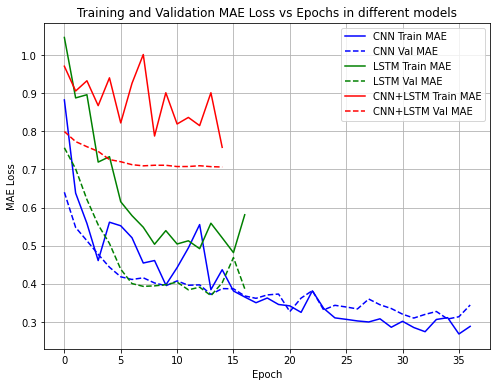

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# CNN
plt.plot(cnn_trainer.history["loss"], label="CNN Train MAE", color="blue")
plt.plot(cnn_trainer.history["val_loss"], label="CNN Val MAE", color="blue", linestyle="--")

# LSTM
plt.plot(lstm_trainer.history["loss"], label="LSTM Train MAE", color="green")
plt.plot(lstm_trainer.history["val_loss"], label="LSTM Val MAE", color="green", linestyle="--")

# CNN+LSTM
plt.plot(cnn_lstm_trainer.history["loss"], label="CNN+LSTM Train MAE", color="red")
plt.plot(cnn_lstm_trainer.history["val_loss"], label="CNN+LSTM Val MAE", color="red", linestyle="--")

plt.title("Training and Validation MAE Loss vs Epochs in different models")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.legend()
plt.grid(True)
plt.show()

# Final Validation MAE

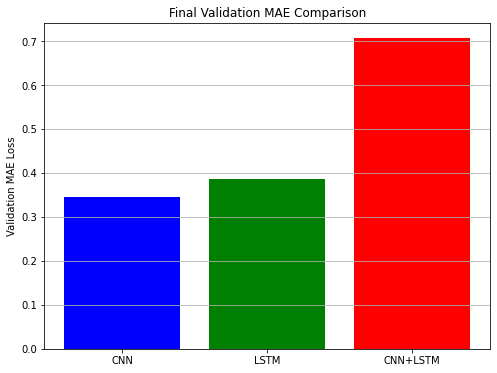

In [21]:
final_val_mae = [
    cnn_trainer.history["val_loss"][-1],
    lstm_trainer.history["val_loss"][-1],
    cnn_lstm_trainer.history["val_loss"][-1]
]

labels = ["CNN", "LSTM", "CNN+LSTM"]

plt.figure(figsize=(8,6))
plt.bar(labels, final_val_mae, color=["blue", "green", "red"])
plt.ylabel("Validation MAE Loss")
plt.title("Final Validation MAE Comparison")
plt.grid(axis="y")
plt.show()

# Predicted vs Actual Plot

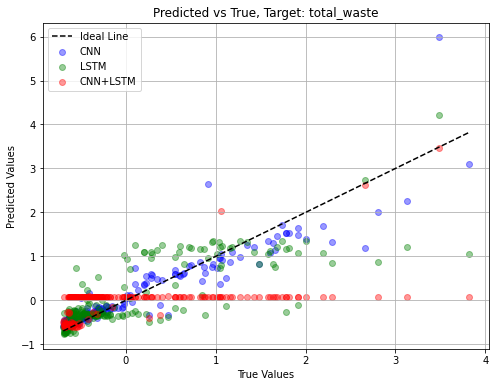

In [22]:
# Generate predictions
y_pred_cnn = cnn_trainer.model.predict(X_v)
y_pred_lstm = lstm_trainer.model.predict(X_v)
y_pred_hybrid = cnn_lstm_trainer.model.predict(X_v)

plt.figure(figsize=(8, 6))

# Only plot first output target: total_waste
true_vals = y_v[:, 0]

plt.scatter(true_vals, y_pred_cnn[:, 0], alpha=0.4, label="CNN", color="blue")
plt.scatter(true_vals, y_pred_lstm[:, 0], alpha=0.4, label="LSTM", color="green")
plt.scatter(true_vals, y_pred_hybrid[:, 0], alpha=0.4, label="CNN+LSTM", color="red")

lims = [true_vals.min(), true_vals.max()]
plt.plot(lims, lims, 'k--', label="Ideal Line")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True, Target: total_waste")
plt.legend()
plt.grid(True)
plt.show()

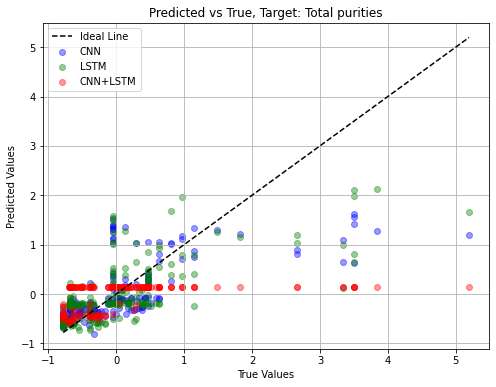

In [23]:
# Generate predictions
plt.figure(figsize=(8, 6))

# Only plot second output target: Total purities
true_vals = y_v[:, 1]

plt.scatter(true_vals, y_pred_cnn[:, 1], alpha=0.4, label="CNN", color="blue")
plt.scatter(true_vals, y_pred_lstm[:, 1], alpha=0.4, label="LSTM", color="green")
plt.scatter(true_vals, y_pred_hybrid[:, 1], alpha=0.4, label="CNN+LSTM", color="red")

lims = [true_vals.min(), true_vals.max()]
plt.plot(lims, lims, 'k--', label="Ideal Line")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True, Target: Total purities")
plt.legend()
plt.grid(True)
plt.show()

# Residual Error Distribution

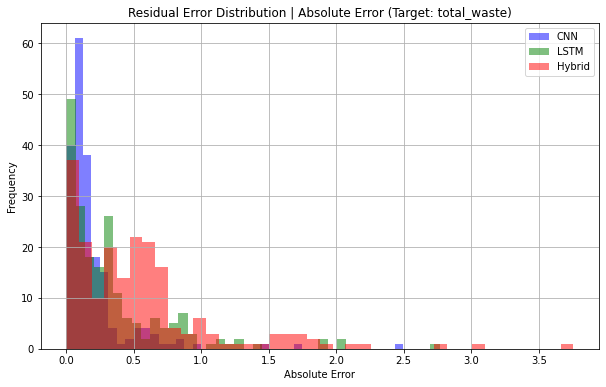

In [24]:
err_cnn = np.abs(y_pred_cnn[:, 0] - y_v[:, 0])
err_lstm = np.abs(y_pred_lstm[:, 0] - y_v[:, 0])
err_hybrid = np.abs(y_pred_hybrid[:, 0] - y_v[:, 0])

plt.figure(figsize=(10,6))
plt.hist(err_cnn, bins=40, alpha=0.5, label="CNN", color="blue")
plt.hist(err_lstm, bins=40, alpha=0.5, label="LSTM", color="green")
plt.hist(err_hybrid, bins=40, alpha=0.5, label="Hybrid", color="red")

plt.title("Residual Error Distribution | Absolute Error (Target: total_waste)")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


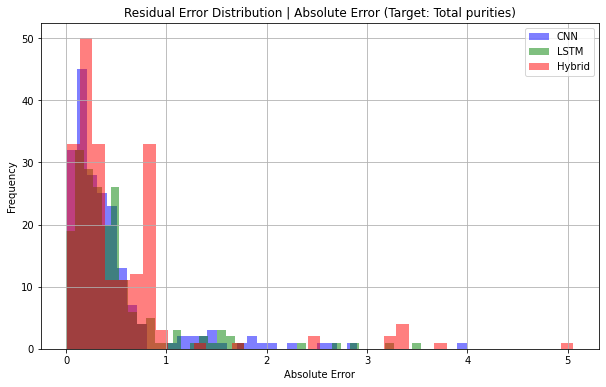

In [25]:
err_cnn = np.abs(y_pred_cnn[:, 1] - y_v[:, 1])
err_lstm = np.abs(y_pred_lstm[:, 1] - y_v[:, 1])
err_hybrid = np.abs(y_pred_hybrid[:, 1] - y_v[:, 1])

plt.figure(figsize=(10,6))
plt.hist(err_cnn, bins=40, alpha=0.5, label="CNN", color="blue")
plt.hist(err_lstm, bins=40, alpha=0.5, label="LSTM", color="green")
plt.hist(err_hybrid, bins=40, alpha=0.5, label="Hybrid", color="red")

plt.title("Residual Error Distribution | Absolute Error (Target: Total purities)")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()
